In [1]:
pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud

Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

In [18]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ganes\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [38]:
fake = pd.read_csv(r"C:\Users\ganes\Downloads\Fake.csv.zip")
true = pd.read_csv(r"C:\Users\ganes\Downloads\True.csv.zip")
print(fake.head())
print(true.head())
fake["label"] = 0  
true["label"] = 1   
data = pd.concat([fake, true])
data = data.sample(frac=1).reset_index(drop=True)  

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

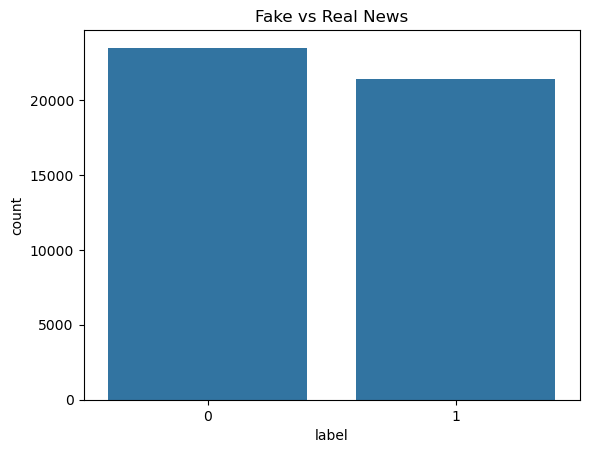

In [39]:
sns.countplot(x=data['label'])
plt.title("Fake vs Real News")
plt.show()

In [40]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
data['text'] = data['text'].apply(clean_text)

In [41]:
from sklearn.model_selection import train_test_split
X = data['text']
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [43]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9859688195991091
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4676
           1       0.98      0.99      0.99      4304

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [49]:
def predict_news(news):
    news = clean_text(news)
    news = vectorizer.transform([news])
    prediction = model.predict(news)
    return "Real News" if prediction[0] == 1 else "Fake News"
print(predict_news("Breaking: Government announces new law"))

Fake News


In [50]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))